# Final Project

#### Imports

In [53]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import string
import time

#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

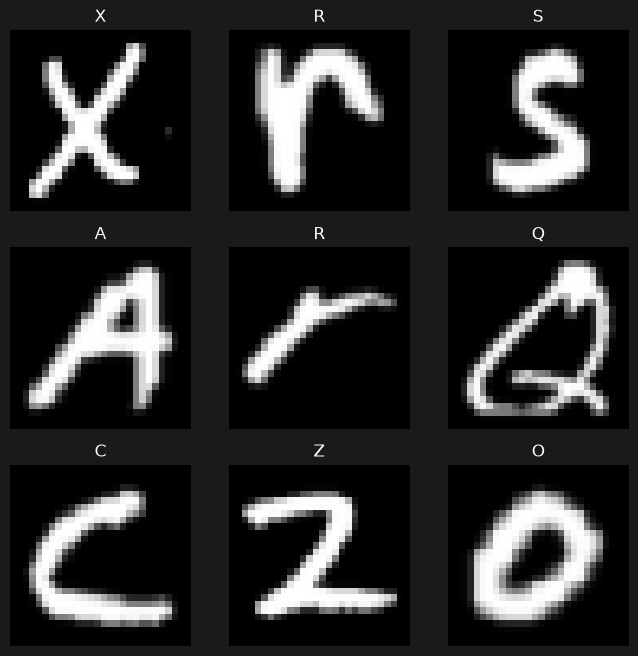

In [54]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [55]:
batch_size = 512

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)


##### Define CNN

In [56]:
model = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 8 * 14 * 14, out_features=26),
)

##### Loss Function and Optimizer

In [57]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

##### Training Function

In [58]:
def train(model, training_loader, criterion, optimizer):
    model.train()

    running_loss = 0
    batch_losses = []

    for images, labels in training_loader:
        labels = labels - 1

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        batch_losses.append(loss.item())

    average_loss = running_loss / len(training_loader)

    return average_loss, batch_losses

##### Test Function

In [59]:
def test(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            labels = labels - 1

            outputs = model(images)
            predictions = outputs.argmax(dim = 1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

##### Training Loop

In [60]:
epochs = 5
loss_history = []

start_time = time.time()

for epoch in range(epochs):
    avg_loss, batch_losses = train(
        model,
        training_loader,
        criterion,
        optimizer
    )

    loss_history.append(batch_losses)

    accuracy = test(model, test_loader)

    print(
        f"Epoch {epoch+1}/{epochs}\n"
        f"Loss {avg_loss:.4f}\n"
        f"Accuracy {accuracy:.2f}%"
    )

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

Epoch 1/5
Loss 1.3831
Accuracy 72.73%
Epoch 2/5
Loss 0.8215
Accuracy 78.90%
Epoch 3/5
Loss 0.6548
Accuracy 82.15%
Epoch 4/5
Loss 0.5589
Accuracy 84.08%
Epoch 5/5
Loss 0.5035
Accuracy 85.22%

Training time: 148.64 seconds


##### Training Loss Plot

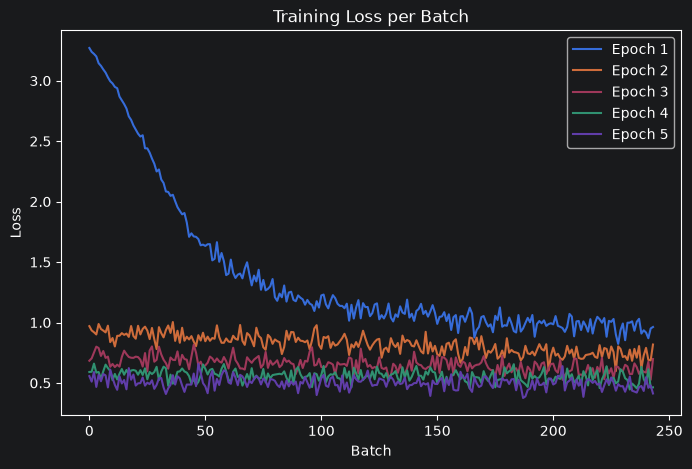

In [61]:
plt.figure(figsize=(8, 5))

for epoch, losses in enumerate(loss_history):
    plt.plot(losses, label=f"Epoch {epoch+1}")

plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training Loss per Batch")
plt.legend()

plt.show()